# Generate an1

In [1]:
import ba137_hyperfine_hamiltonian_solver as hfs
import numpy

In [32]:
mag_field_sen = hfs.generate_magnetic_field_sensitivity(4.2095)

In [ ]:
6*10*34

In [33]:
print(mag_field_sen)

[[ 4.57267845e+00  3.87015386e+00  3.16866067e+00  2.46819545e+00
   1.76875480e+00]
 [ 1.74619965e+00  1.04367506e+00  3.42181875e-01 -3.58283351e-01
  -1.05772399e+00]
 [-1.24348768e+00 -1.94601227e+00 -2.64750546e+00 -3.34797068e+00
  -4.04741133e+00]
 [ 4.66112907e+00  3.95860448e+00  3.25711129e+00  2.55664608e+00
   1.85720543e+00]
 [ 3.00826601e+00  2.30574142e+00  1.60424823e+00  9.03783011e-01
   2.04342364e-01]
 [ 1.40406195e+00  7.01537356e-01  4.41696102e-05 -7.00421051e-01
  -1.39986169e+00]
 [-1.14008058e-01 -8.16532647e-01 -1.51802584e+00 -2.21849106e+00
  -2.91793170e+00]
 [-1.47278675e+00 -2.17531135e+00 -2.87680453e+00 -3.57726975e+00
  -4.27671040e+00]
 [ 5.60077588e+00  4.89825129e+00  4.19675810e+00  3.49629287e+00
   2.79685223e+00]
 [ 4.60550301e+00  3.90297841e+00  3.20148523e+00  2.50102001e+00
   1.80157936e+00]
 [ 3.54247061e+00  2.83994603e+00  2.13845284e+00  1.43798762e+00
   7.38546969e-01]
 [ 2.44049724e+00  1.73797265e+00  1.03647946e+00  3.36014241e-01

In [34]:
def get_sen(transitions,matrix = mag_field_sen):
    pi_times_list = []
    col_labels = [-2, -1, 0, 1, 2]
    for transition in transitions:
        row_label = [transition[1],transition[2]]
        Fs = [1,2,3,4]
        states = []
        for i in Fs:
            for j in range(2*i+1):
                mF = i-j
                states.append([i,mF])
    
        row_labels = states
    
        col_label = transition[0]
    
        # Find the index of the row label
        row_index = next((i for i, label in enumerate(row_labels) if label == row_label), None)
        # Find the index of the column label
        col_index = col_labels.index(col_label)
        
        if row_index is not None and col_index in range(len(col_labels)):
            pi_times_list.append(matrix[row_index, col_index])
        else:
            pi_times_list.append(np.nan)

    return pi_times_list

In [36]:
an1_mat = (mag_field_sen - get_sen([[0,2,0]])[0])/(get_sen([[-1,4,-3]])[0] -  get_sen([[0,2,0]])[0])
display(an1_mat)

array([[-1.30673584, -1.10597322, -0.90550534, -0.70533123, -0.50544991],
       [-0.49900425, -0.29824163, -0.09777375,  0.10240036,  0.30228168],
       [ 0.35536794,  0.55613057,  0.75659845,  0.95677256,  1.15665388],
       [-1.33201265, -1.13125003, -0.93078215, -0.73060804, -0.53072672],
       [-0.85966886, -0.65890623, -0.45843836, -0.25826424, -0.05838293],
       [-0.4012305 , -0.20046788, -0.        ,  0.20017411,  0.40005543],
       [ 0.03259306,  0.23335568,  0.43382356,  0.63399767,  0.83387899],
       [ 0.42089545,  0.62165807,  0.82212595,  1.02230007,  1.22218138],
       [-1.60053842, -1.3997758 , -1.19930792, -0.99913381, -0.79925249],
       [-1.31611622, -1.11535359, -0.91488571, -0.7147116 , -0.51483029],
       [-1.01233016, -0.81156754, -0.61109966, -0.41092555, -0.21104423],
       [-0.69741582, -0.4966532 , -0.29618532, -0.09601121,  0.10387011],
       [-0.37346279, -0.17270017,  0.02776771,  0.22794182,  0.42782314],
       [-0.0380727 ,  0.16268993,  0.3

# Generate an2

## Calibration Data analysis

In [25]:
import os
import json
from datetime import datetime

# # Define the folder containing the files
folder_path = "Z:\\Lab Data\\D52_Calibration_Ba137\\RFSoC_Fast_Ramsey_calibrations"
# Define date-time filter (Modify as needed)
start_date = datetime(2025, 11, 18, 19, 0, 0)  # Change to desired start datetime
end_date = datetime(2025, 11, 21, 0, 20, 59)  # Change to desired end datetime (Optional)
# folder_path = "Z:\\Lab Data\\D52_Calibration_Ba137\\Fast_Ramsey_calibrations"
# start_date = datetime(2025, 3, 1, 0, 0, 0)  # Change to desired start datetime
# end_date = datetime(2025, 6, 25, 11, 6, 59)  # Change to desired end datetime (Optional)


# Lists to store the extracted data
list_freqs = []
list_triplets = []

# Iterate through all files in the folder
for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)

    # Skip if not a file
    if not os.path.isfile(file_path):
        continue

    # Get file modification time
    mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))

    # Check if the file is within the date-time range
    if mod_time < start_date or mod_time > end_date:
        continue  # Skip files outside the range

    # Read the file and process its contents
    with open(file_path, 'r') as file:
        try:
            # Read lines from the file
            lines = file.readlines()
            # Parse the bottom list of lists (second line)
            bottom_list = json.loads(lines[1].strip())
            list_triplets.append(bottom_list)
            # Parse the top list (first line)
            top_list = json.loads(lines[0].strip())
            list_freqs.append(top_list)

        except (IndexError, json.JSONDecodeError) as e:
            print(f"Error processing file {filename}: {e}")

# Display the results
print("Files processed:", len(list_freqs))
print("list_freqs:", len(list_freqs))
print("list_triplets:", len(list_triplets))



Files processed: 287
list_freqs: 287
list_triplets: 287


In [26]:
import numpy as np

combined = list(zip(list_freqs, list_triplets))

# Sort combined lists based on the third entry in lists inside list_triplets
combined.sort(key=lambda x: x[1][2])

# Unzip sorted lists back into separate lists
list_freqs, list_triplets = zip(*combined)

# Convert back to lists (if needed)
list_freqs = list(list_freqs)
list_triplets = list(list_triplets)
# Display the results
# print("list_freqs:", list_freqs)
print("list_triplets:", np.array(list_triplets))

list_triplets: [[[ 0  2  0]
  [-1  4 -3]
  [-2  1 -1]]

 [[ 0  2  0]
  [-1  4 -3]
  [-2  1 -1]]

 [[ 0  2  0]
  [-1  4 -3]
  [-2  1 -1]]

 ...

 [[ 0  2  0]
  [-1  4 -3]
  [ 2  4  4]]

 [[ 0  2  0]
  [-1  4 -3]
  [ 2  4  4]]

 [[ 0  2  0]
  [-1  4 -3]
  [ 2  4  4]]]


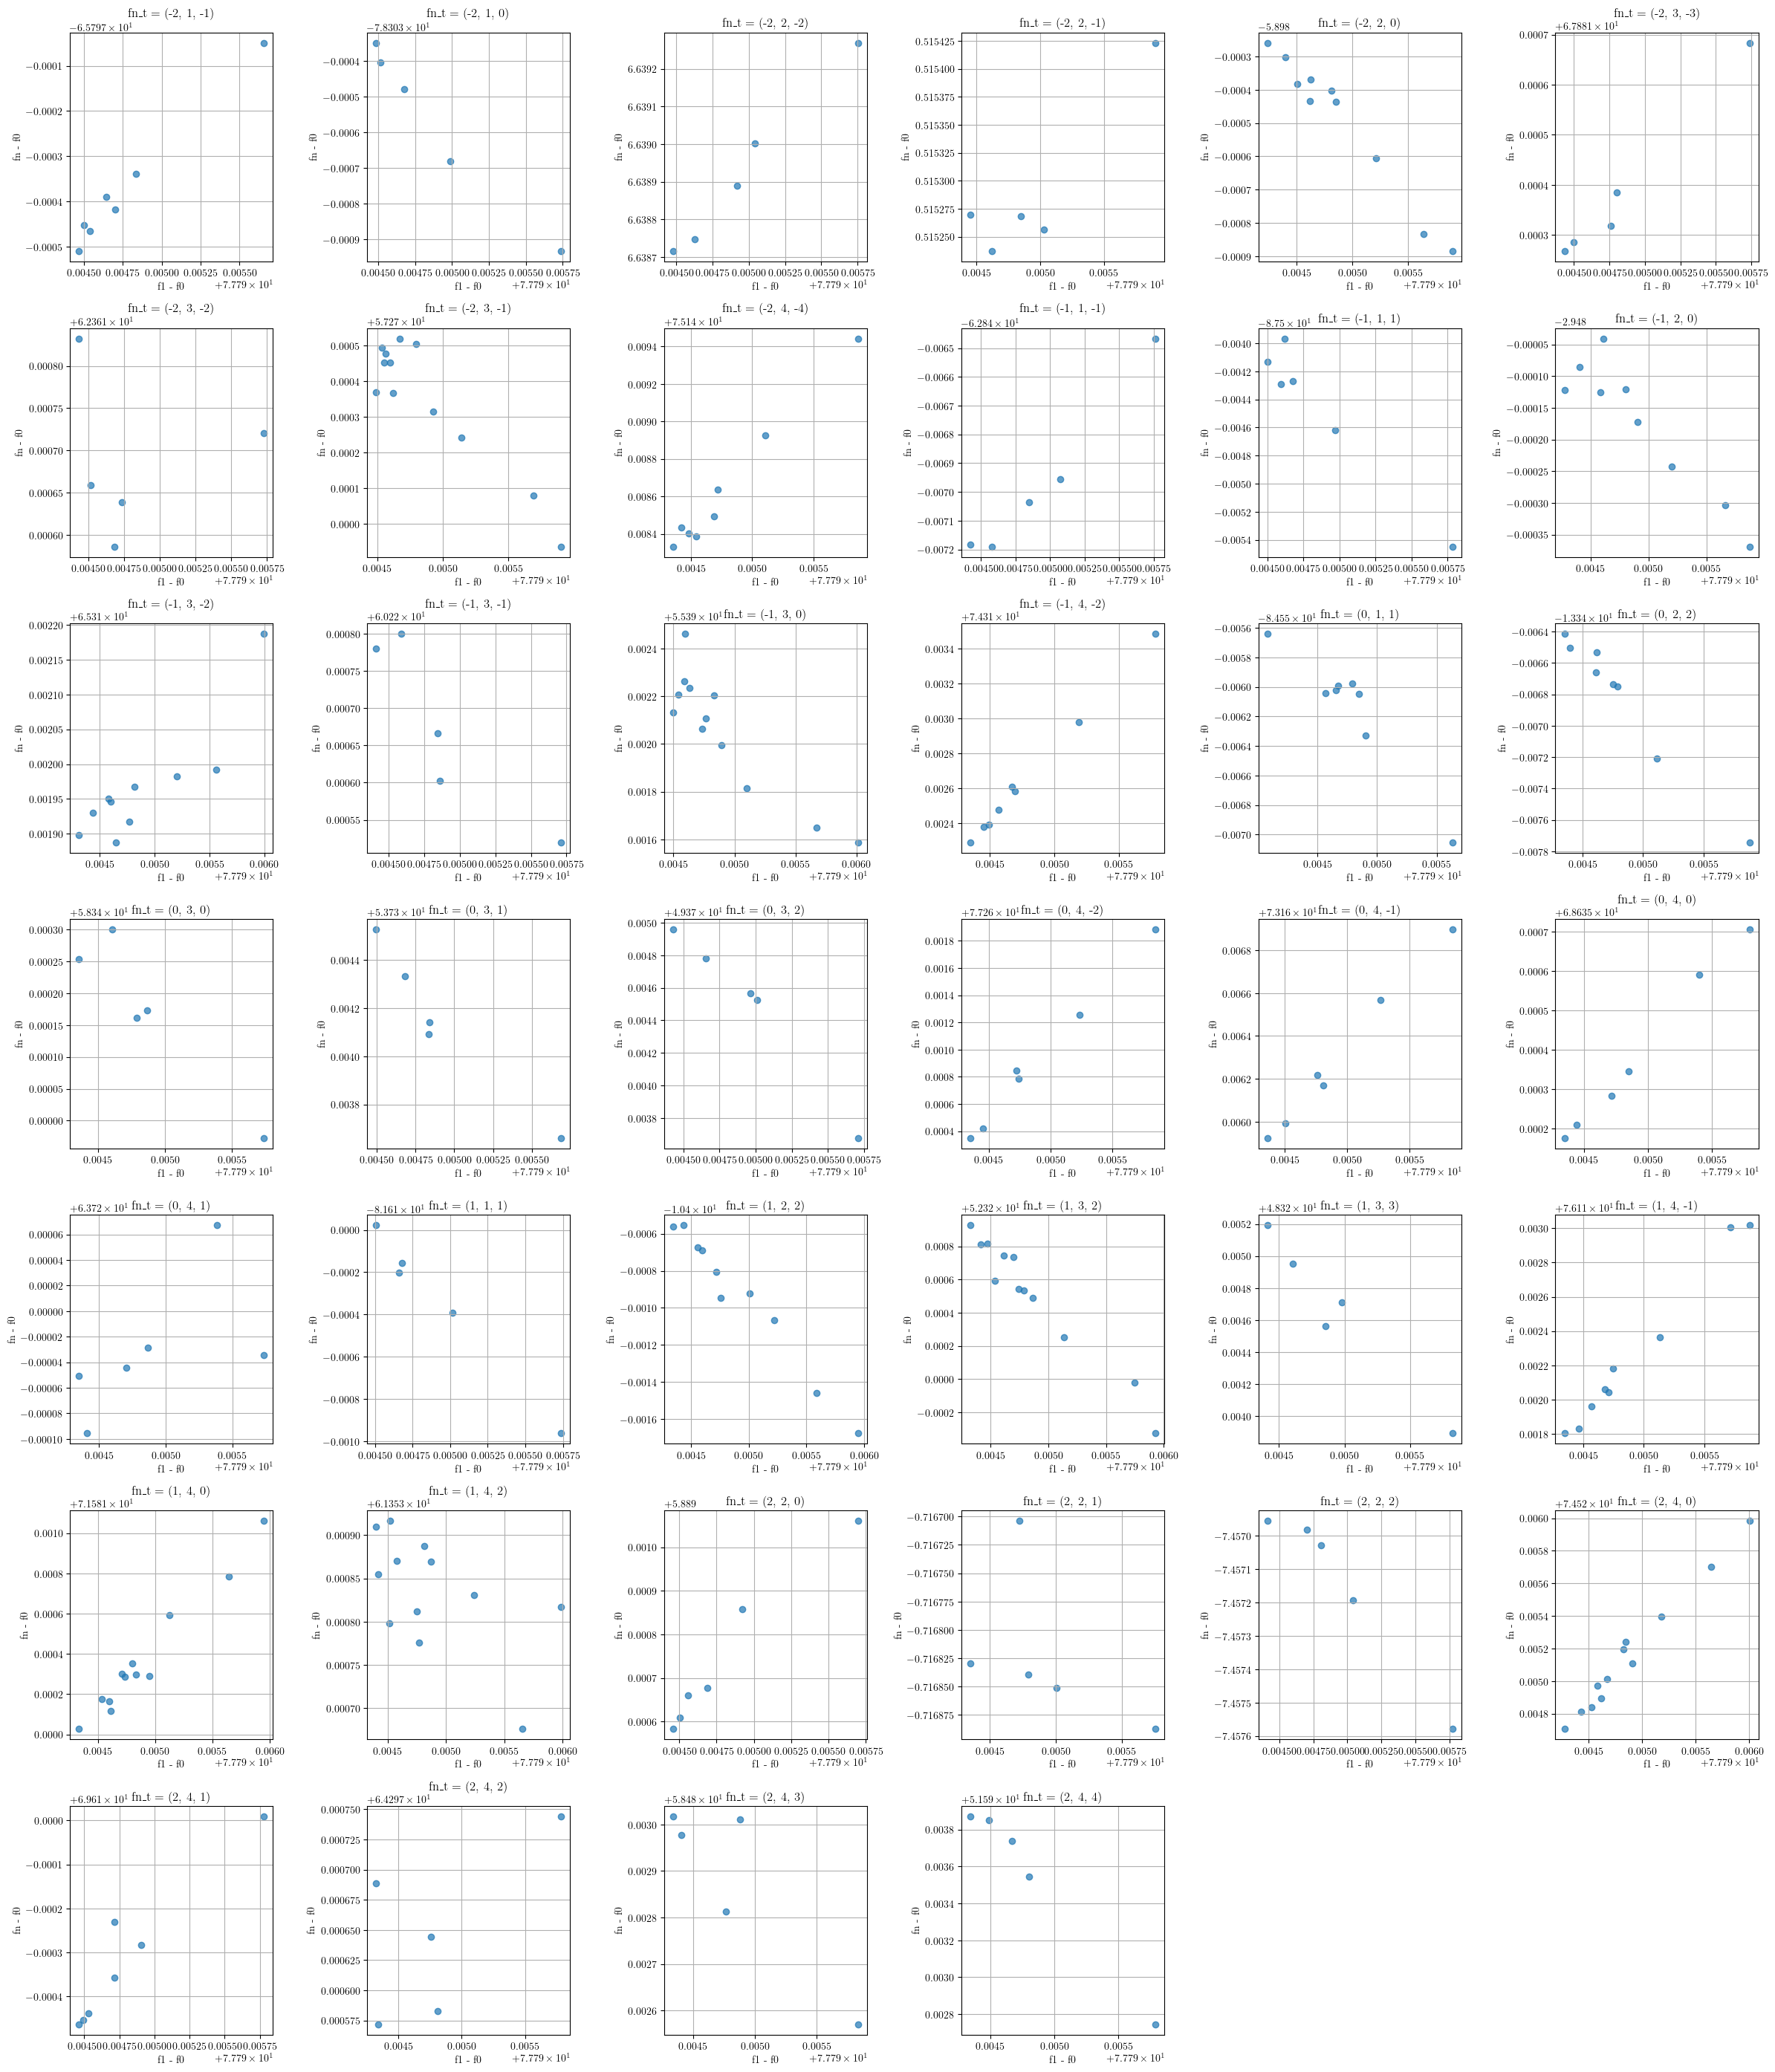

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure list_freqs and list_triplets exist from the previous script
# Unique third entries from list_triplets (fn_t values)
unique_fn_t = sorted(set(tuple(triplet[2]) if isinstance(triplet[2], list) else triplet[2] for triplet in list_triplets))

# Number of columns for the subplot grid
columns = 6
rows = (len(unique_fn_t) + columns - 1) // columns

# Create a grid of subplots
fig, axes = plt.subplots(rows, columns, figsize=(columns * 4, rows * 4))
axes = axes.flatten()

for i, fn_t in enumerate(unique_fn_t):
    x_vals = []
    y_vals = []

    # Filter corresponding entries for the current fn_t
    for freqs, triplet in zip(list_freqs, list_triplets):
        current_fn_t = tuple(triplet[2]) if isinstance(triplet[2], list) else triplet[2]
        if current_fn_t == fn_t:
            f0, f1, fn = freqs
            x_vals.append(f1 - f0)
            y_vals.append(fn - f0)

    # Convert to numpy arrays for plotting
    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)

    # Plot in the corresponding subplot
    ax = axes[i]
    ax.scatter(x_vals, y_vals, alpha=0.7)
    ax.set_title(f"fn_t = {fn_t}")
    ax.set_xlabel("f1 - f0")
    ax.set_ylabel("fn - f0")
    ax.grid(True)

# Hide any unused subplots
for j in range(len(unique_fn_t), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


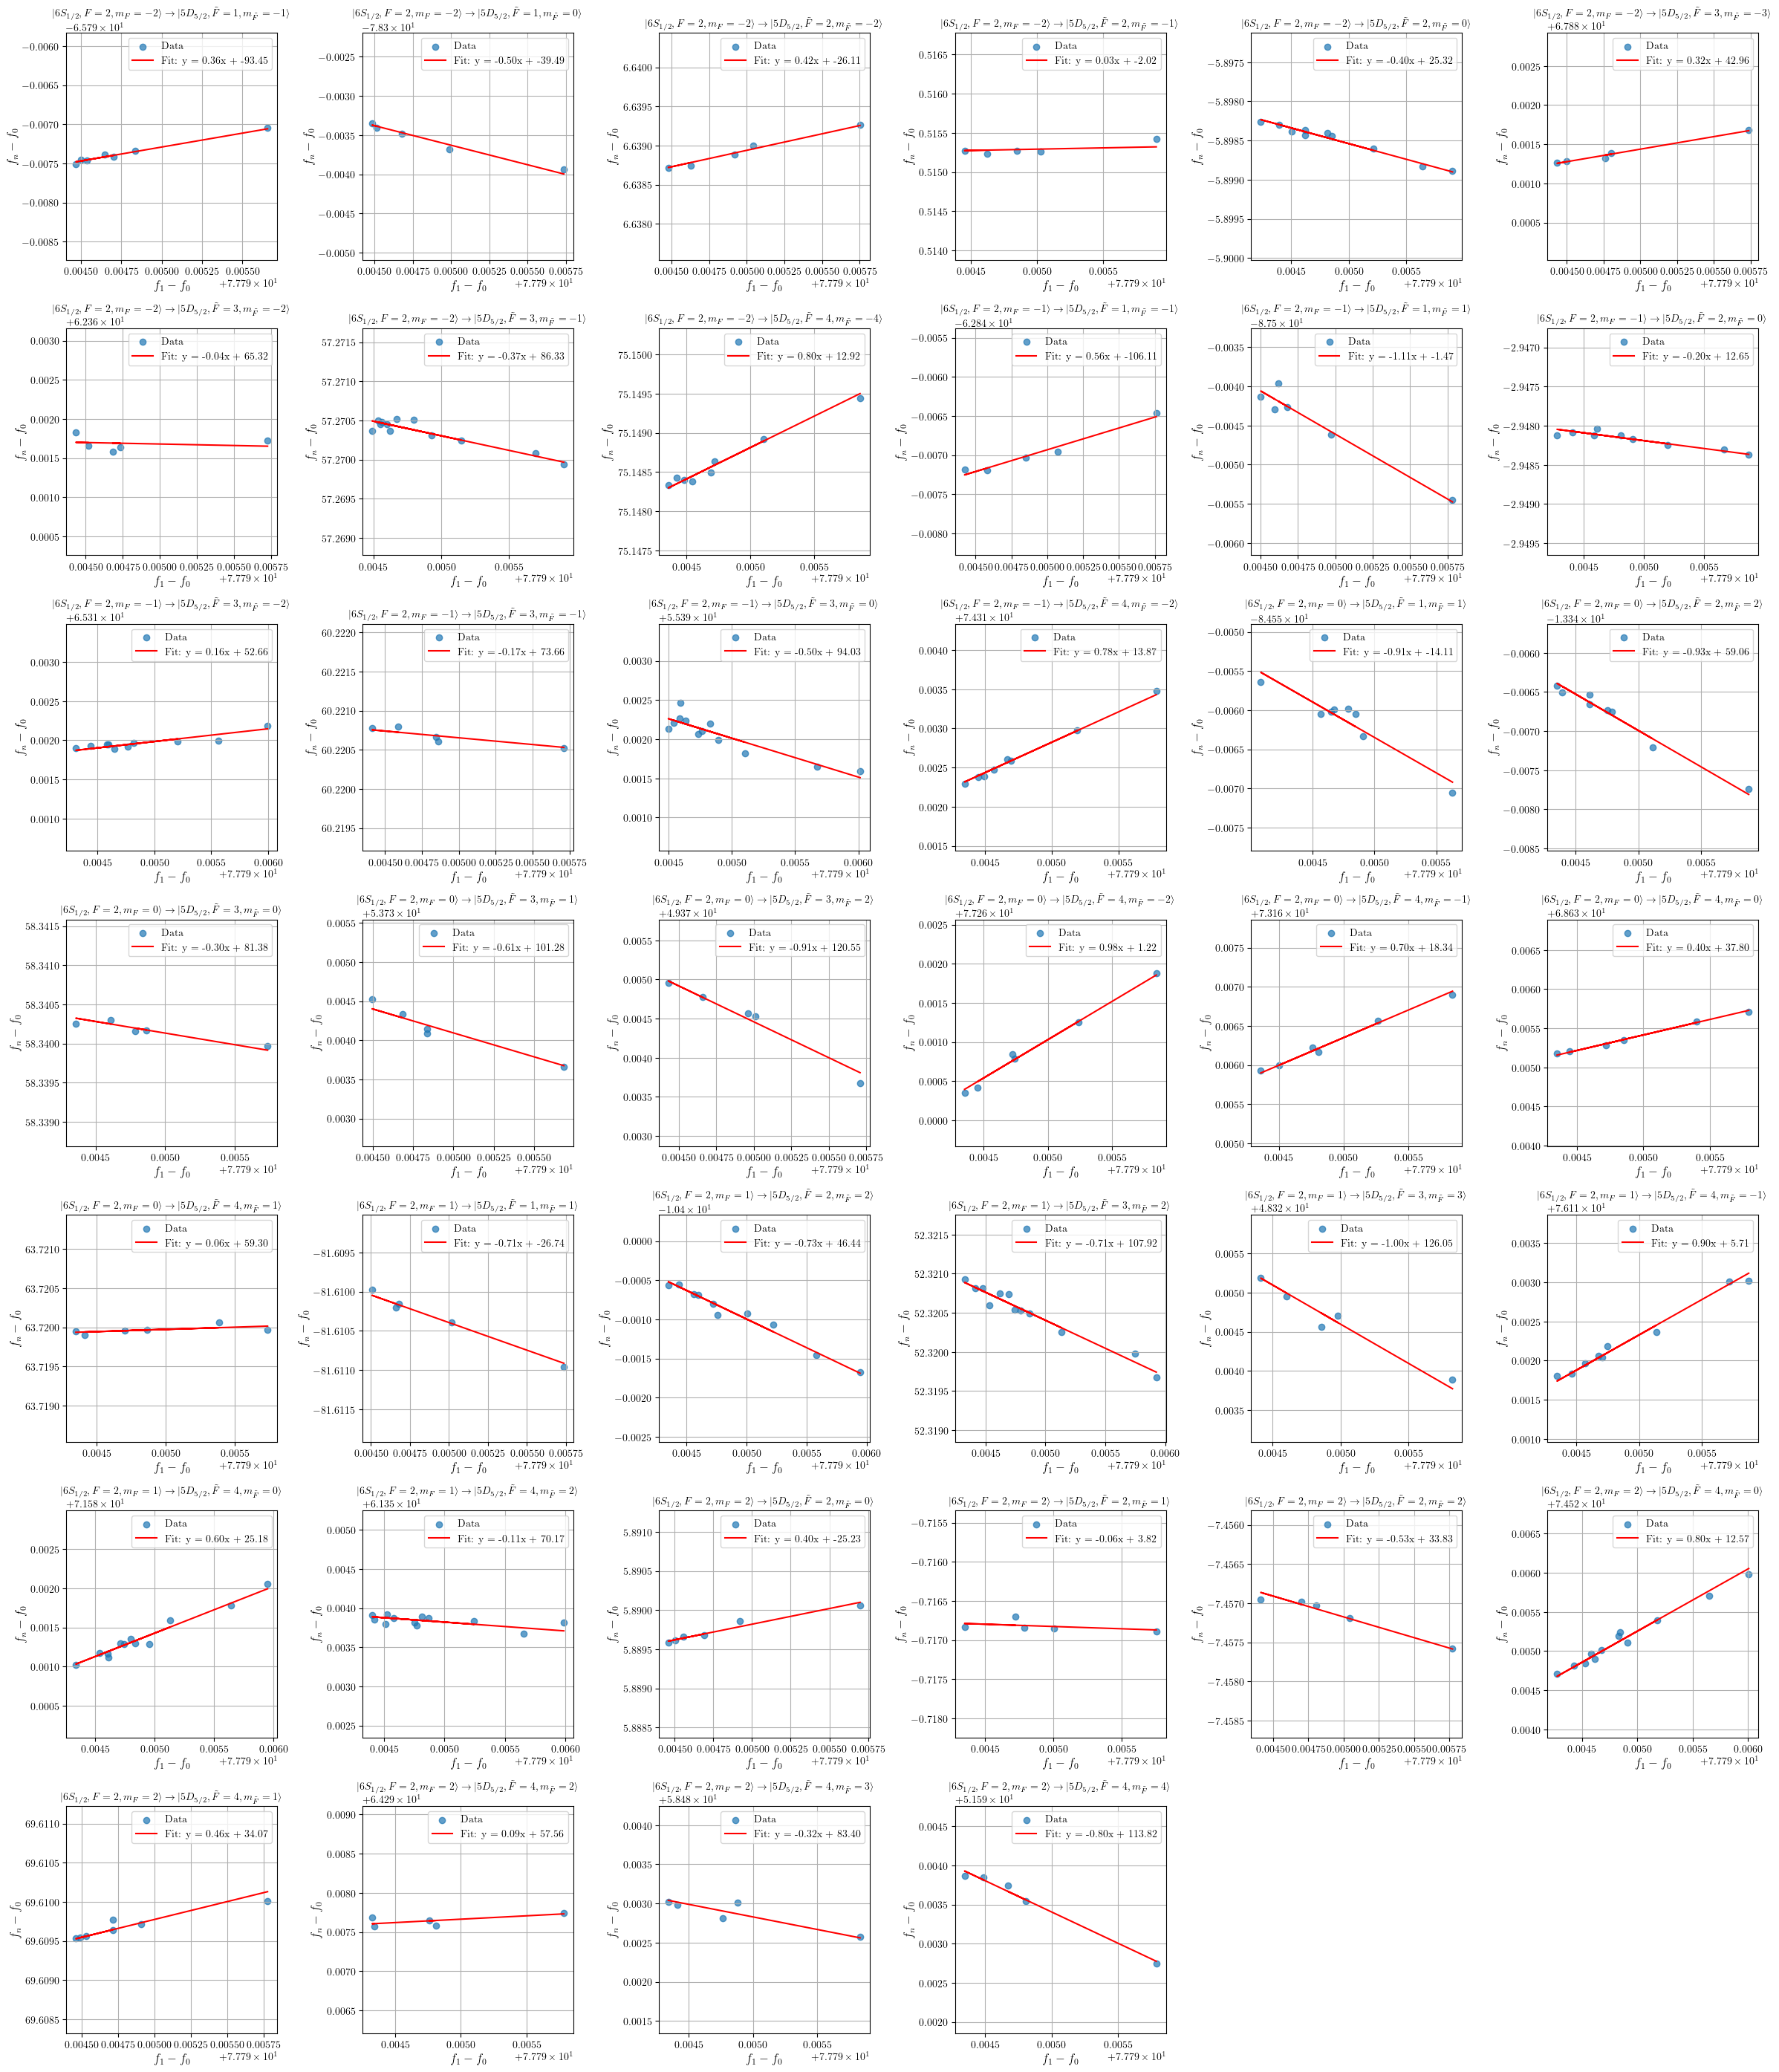

In [28]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

import numpy as np
from scipy.optimize import curve_fit

# Ensure list_freqs and list_triplets exist from the previous script
# Unique third entries from list_triplets (fn_t values)
unique_fn_t = sorted(set(tuple(triplet[2]) if isinstance(triplet[2], list) else triplet[2] for triplet in list_triplets))

# Function to fit: y = m*x + b, where m is the known slope
def linear_model(x, b, m):
    return m * x + b

# Number of columns for the subplot grid
columns = 6
rows = (len(unique_fn_t) + columns - 1) // columns

# Create a grid of subplots
fig, axes = plt.subplots(rows, columns, figsize=(columns * 4, rows * 4))
axes = axes.flatten()
y_ranges = []

trans_list = []
an2_list = []
deviations = []
for i, fn_t in enumerate(unique_fn_t):
    x_vals = []
    y_vals = []

    # Filter corresponding entries for the current fn_t
    for freqs, triplet in zip(list_freqs, list_triplets):
        current_fn_t = tuple(triplet[2]) if isinstance(triplet[2], list) else triplet[2]
        if current_fn_t == fn_t:
            f0, f1, fn = freqs
            x_vals.append(f1 - f0)
            y_vals.append(fn - f0)

    # Convert to numpy arrays for plotting and fitting
    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)
    y_ranges.append(max(y_vals)-min(y_vals))
    # Get the slope from the function for the current triplet
    # print(fn_t)
    slope = get_sen([list(fn_t)],an1_mat)[0]
    # print(slope)
    # Fit the data to find the y-intercept
    popt, _ = curve_fit(lambda x, b: linear_model(x, b, slope), x_vals, y_vals)
    y_intercept = popt[0]

    fitted_line = linear_model(x_vals, y_intercept, slope)

    deviation = y_vals - fitted_line
    deviations.append(deviation)
    trans_list.append(list(fn_t))
    an2_list.append(y_intercept)
    # Plot in the corresponding subplot
    ax = axes[i]
    ax.scatter(x_vals, y_vals, alpha=0.7, label="Data")
    ax.plot(x_vals, linear_model(x_vals, y_intercept, slope), color='red', label=f"Fit: y = {slope:.2f}x + {y_intercept:.2f}")
    ax.set_title(rf"$|6S_{{1/2}},F=2,m_F = {fn_t[0]}\rangle \rightarrow |5D_{{5/2}},\tilde{{F}}={fn_t[1]}, m_{{\tilde{{F}}}} = {fn_t[2]} \rangle$", fontsize = 10)
    ax.set_xlabel(r"$f_1 - f_0$", fontsize = 12)
    ax.set_ylabel(r"$f_n - f_0$", fontsize = 12)
    ax.set_ylim(min(y_vals) + (max(y_vals)-min(y_vals))/2 - 0.0029/2, min(y_vals) + (max(y_vals)-min(y_vals))/2 + 0.0029/2)
    ax.legend()
    ax.grid(True)

# Hide any unused subplots
for j in range(len(unique_fn_t), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
# plt.savefig('fitted_calibration_data.png',dpi = 800)
plt.savefig('Example_calibration_data.png', dpi=800)
plt.show()


In [29]:
matrix_dummy = np.arange(1, 121).reshape(24, 5)
def fill_matrix(labels,numbers,mat):
    combined_data = zip(labels,numbers)
    for i,j in combined_data:
        index = np.where(matrix_dummy == get_sen([i],matrix_dummy)[0])
        mat[index] =  j
    return mat

In [30]:
nan_mat = np.full((24, 5), np.nan)
print(len(trans_list))
an2_mat = fill_matrix(trans_list,an2_list,nan_mat)

40


In [31]:
print(an2_mat)

[[          nan   -1.46727613  -14.11443897  -26.74106764           nan]
 [ -39.48697649           nan           nan           nan           nan]
 [ -93.4465746  -106.11455822           nan           nan           nan]
 [          nan           nan   59.06171819   46.43513206   33.82913753]
 [          nan           nan           nan           nan    3.82428733]
 [  25.31522915   12.64723417           nan           nan  -25.23257713]
 [  -2.02022206           nan           nan           nan           nan]
 [ -26.10691297           nan           nan           nan           nan]
 [          nan           nan           nan  126.05244088           nan]
 [          nan           nan  120.54932319  107.92268652           nan]
 [          nan           nan  101.27657786           nan           nan]
 [          nan   94.03140071   81.38409693           nan           nan]
 [  86.32587081   73.65787715           nan           nan           nan]
 [  65.3248047    52.65676478           nan        

# Analysis of deviations